# Data Exploration

Data Description
* Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers
* X1 = my order was delivered on time
* X2 = contents of my order was as I expected
* X3 = I ordered everything I wanted to order
* X4 = I paid a good price for my order
* X5 = I am satisfied with my courier
* X6 = the app makes ordering easy for me

In [1]:
%%capture
%pip install -U statsmodels

In [2]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [3]:
df = pd.read_csv('../data/ACME-HappinessSurvey2020.csv')
df.columns = ['customer satisfaction',
              'my order was delivered on time',
              'contents of my order was as I expected',
              'I ordered everything I wanted to order',
              'I paid good price for my order',
              'I am satisfied with my courier',
              'the app makes ordering easy'
              ]
df.head()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [4]:
print(f'There are {df.shape[0]} observations and {len(df.columns[1:])} features in the dataset.')

There are 126 observations and 6 features in the dataset.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   customer satisfaction                   126 non-null    int64
 1   my order was delivered on time          126 non-null    int64
 2   contents of my order was as I expected  126 non-null    int64
 3   I ordered everything I wanted to order  126 non-null    int64
 4   I paid good price for my order          126 non-null    int64
 5   I am satisfied with my courier          126 non-null    int64
 6   the app makes ordering easy             126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


In [6]:
for col in df.columns:
    df[col] = df[col].astype('int8')

In [7]:
from pathlib import Path

path = Path('../data/ACME-HappinessSurvey2020_shrunk.csv')

if path.exists():
    print('Path already exists.')
else:
    df.to_csv('../data/ACME-HappinessSurvey2020_shrunk.csv', index=False)

Path already exists.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   customer satisfaction                   126 non-null    int8 
 1   my order was delivered on time          126 non-null    int8 
 2   contents of my order was as I expected  126 non-null    int8 
 3   I ordered everything I wanted to order  126 non-null    int8 
 4   I paid good price for my order          126 non-null    int8 
 5   I am satisfied with my courier          126 non-null    int8 
 6   the app makes ordering easy             126 non-null    int8 
dtypes: int8(7)
memory usage: 1010.0 bytes


We can see that there are no missing values present in either the target variable (customer satisfaction) or the feature variables.

Of the 126 instances, we can assume that they are all unique customer surveys.

In [9]:
df.describe()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


The descriptive statistics show us, as we expected, the target variable shows a max of 1 and min of 0 and the values of the feature variables vary from min of 1 and max of 5.

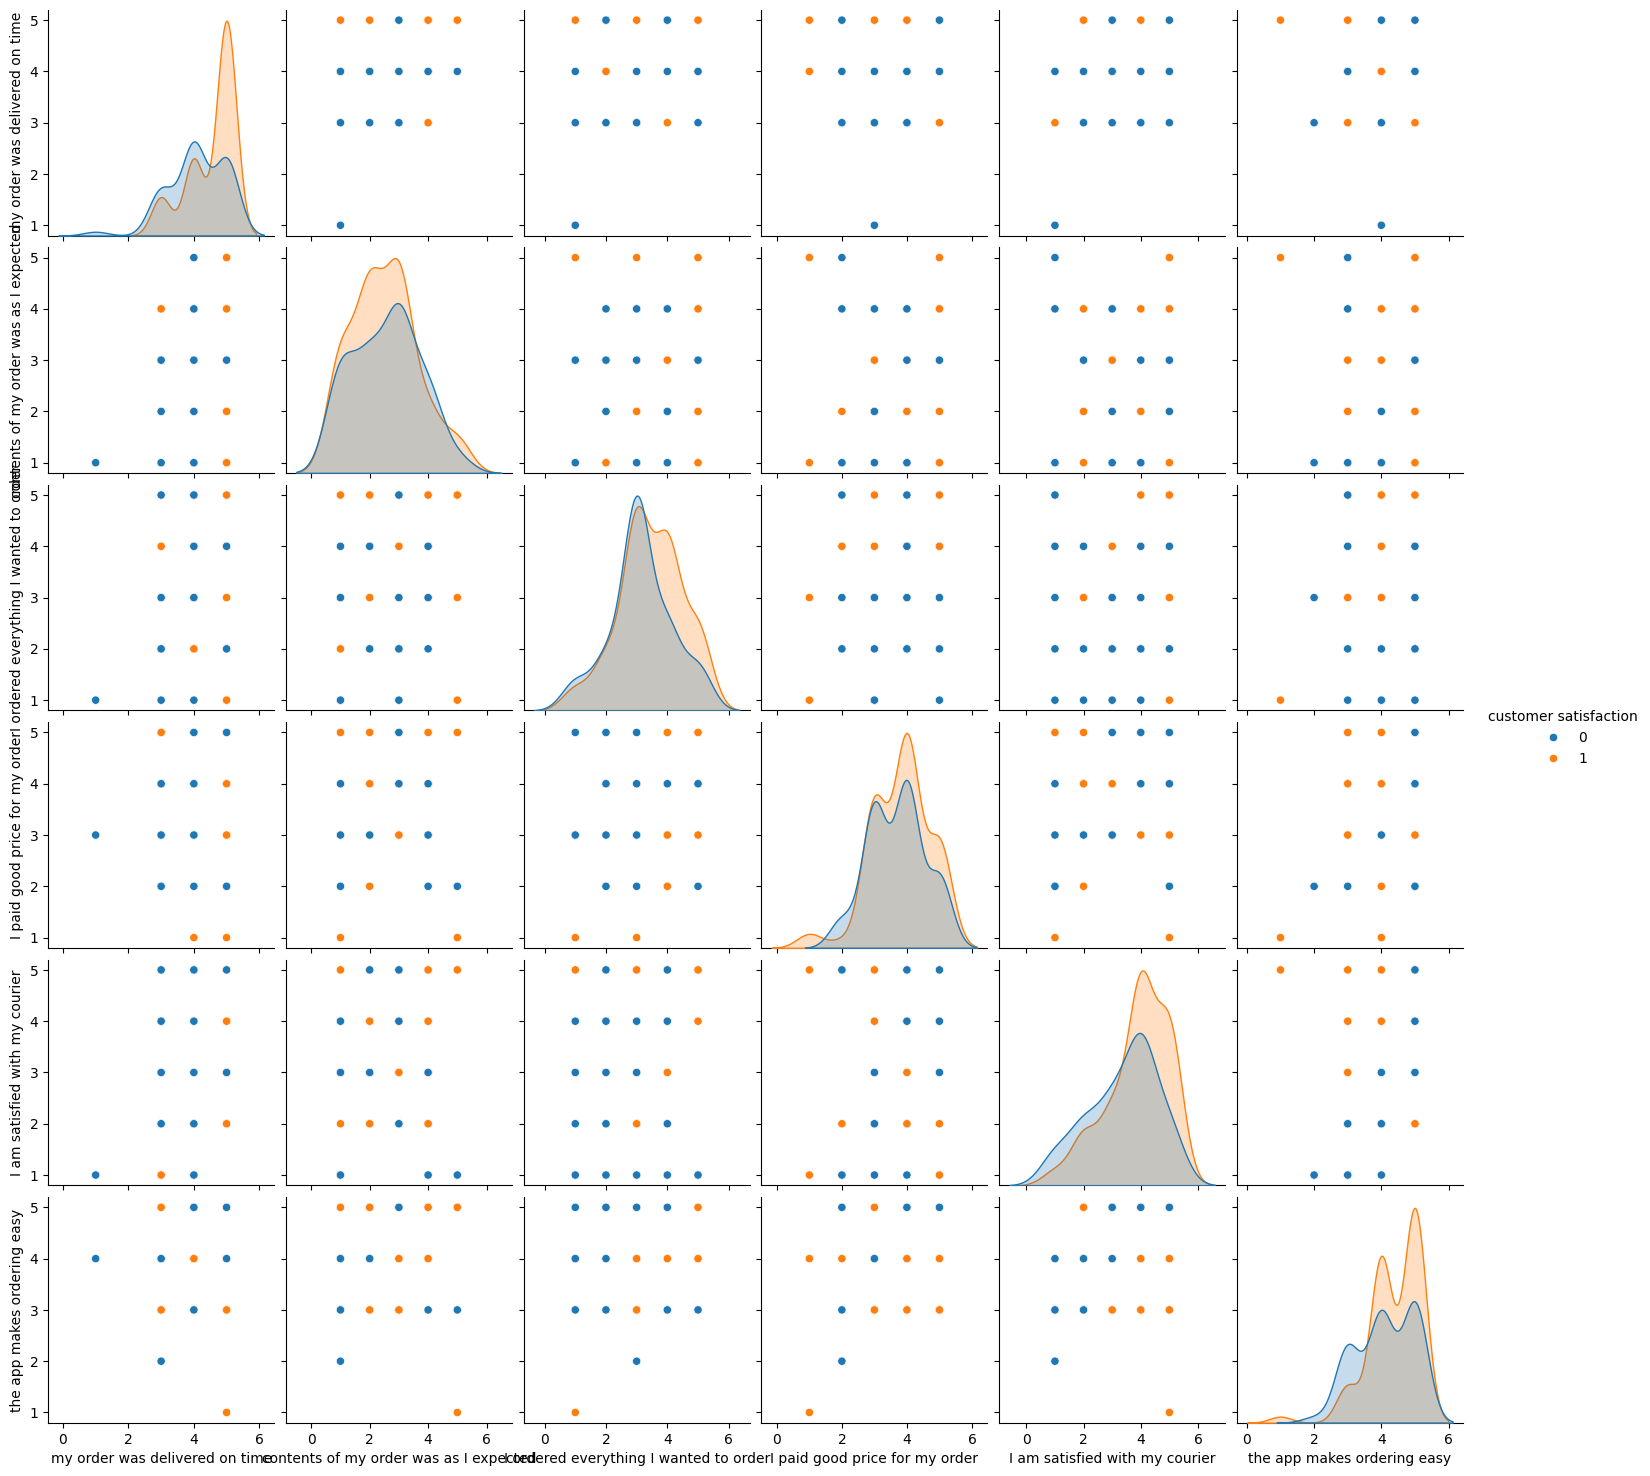

In [10]:
sns.pairplot(data=df, hue='customer satisfaction')
plt.show()

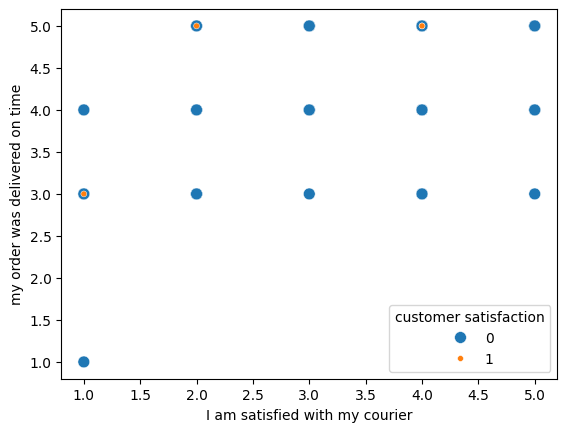

In [ ]:
## example of trying to examine both classes overlap with discrete values

sns.scatterplot(df,
x=df['I am satisfied with my courier'],
y=df['my order was delivered on time'],
hue='customer satisfaction', size='customer satisfaction')
plt.show()

### Distributions of Questions

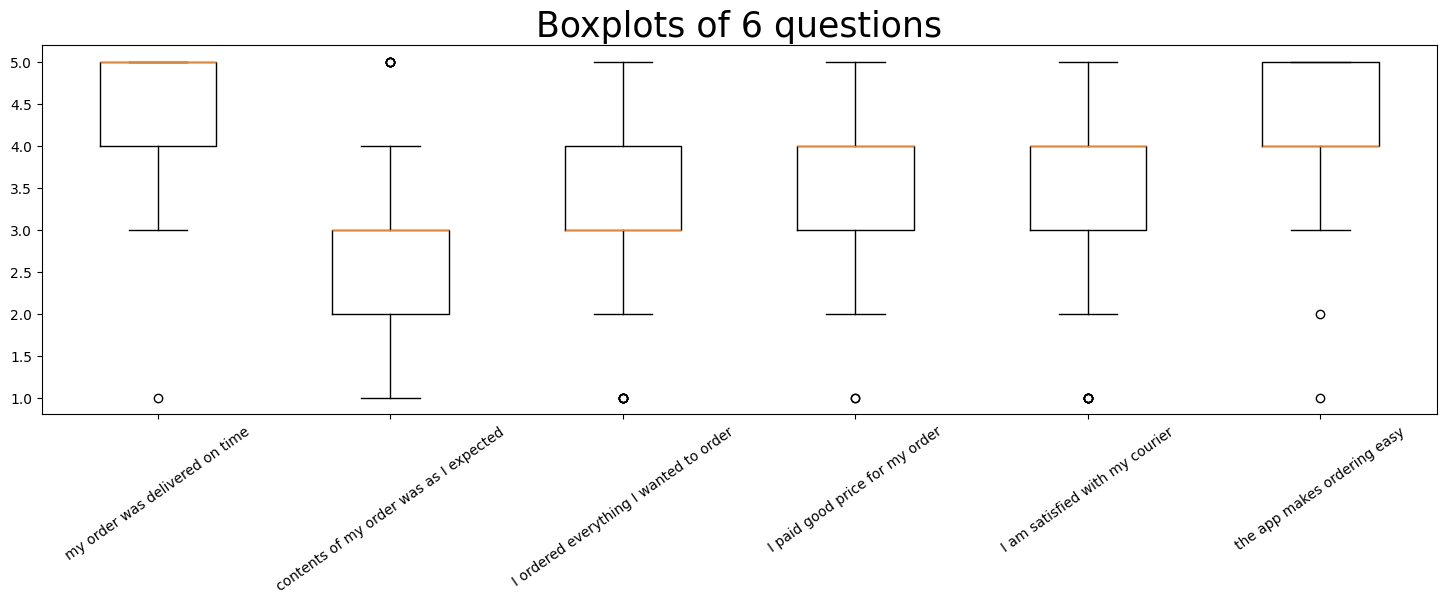

In [12]:
fig, ax = plt.subplots()

fig.set_figwidth(18)
ax.boxplot(df.iloc[:, 1:], labels=df.columns[1:])
plt.title("Boxplots of 6 questions", fontdict={'fontsize':25})
plt.xticks(rotation=35)
plt.show()

The boxplots show a few "outliers" in the questions which are influencing the skew of the distribution of the questions. I use outliers here only for the reason that I am using boxplots to show the spread of the data and that is the terminology used for the points outside of the box and whiskers of the plots.

To look at how many of said outliers we have lets look at a count of each feature variable.

In [13]:
## creates a list of dictionaries that correspond to feature variables value counts for each 1-5 option of questionaire

feature_counts = [df[col].value_counts(sort=False).to_dict() for col in df.columns[1:]]

In [14]:
### make a DataFrame that houses all the counts of each question

count_df = pd.DataFrame({df.columns[1]: feature_counts[0],
                         df.columns[2]: feature_counts[1],
                         df.columns[3]: feature_counts[2],
                         df.columns[4]: feature_counts[3],
                         df.columns[5]: feature_counts[4],
                         df.columns[6]: feature_counts[5]
                         })

count_df

,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
3,20.0,42,55,41,22,20
5,65.0,6,17,25,31,57
4,40.0,17,33,53,50,47
1,1.0,27,7,2,7,1
2,NaN,34,14,5,16,1


In [15]:
count_df.fillna(0)

,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
3,20.0,42,55,41,22,20
5,65.0,6,17,25,31,57
4,40.0,17,33,53,50,47
1,1.0,27,7,2,7,1
2,0.0,34,14,5,16,1


By looking at each features counts of each number option of the survey we can see that those outliers that I mentioned above are not substantial enough to worry about.

For all of the questions except the 2nd one the outlier was the 1 option and by looking at the table above the 1 option only counts from anywhere between 1 response to 7 responses.

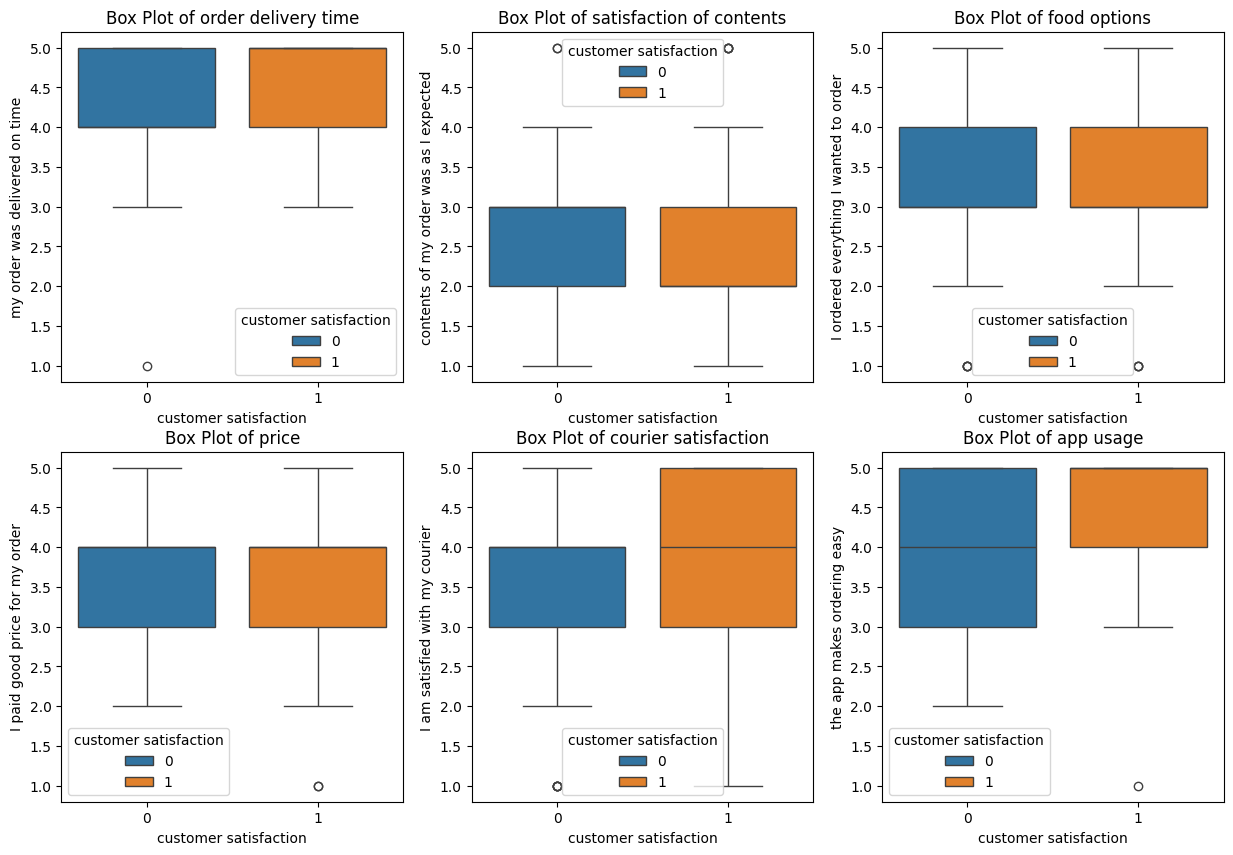

In [16]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(x='customer satisfaction', y='my order was delivered on time', data=df, hue='customer satisfaction')
plt.title('Box Plot of order delivery time')
plt.subplot(2, 3, 2)
sns.boxplot(x='customer satisfaction', y='contents of my order was as I expected', data=df, hue='customer satisfaction')
plt.title('Box Plot of satisfaction of contents')
plt.subplot(2, 3, 3)
sns.boxplot(x='customer satisfaction', y='I ordered everything I wanted to order', data=df, hue='customer satisfaction')
plt.title('Box Plot of food options')
plt.subplot(2, 3, 4)
sns.boxplot(x='customer satisfaction', y='I paid good price for my order', data=df, hue='customer satisfaction')
plt.title('Box Plot of price')
plt.subplot(2, 3, 5)
sns.boxplot(x='customer satisfaction', y='I am satisfied with my courier', data=df, hue='customer satisfaction')
plt.title('Box Plot of courier satisfaction')
plt.subplot(2, 3, 6)
sns.boxplot(x='customer satisfaction', y='the app makes ordering easy', data=df, hue='customer satisfaction')
plt.title('Box Plot of app usage')
plt.show()

As mentioned above the outliers can be seen in numerous plots; there are not a lot per se, but we have a better visual of why the mean and median are diverging. Although most, if not all, the distributions of the two classes of customers overlap, the two plots where we notice a difference between the two types of customers is in thier courier satisfaction scores and how easy the app made it to order their food (the last two plots on the bottom row).

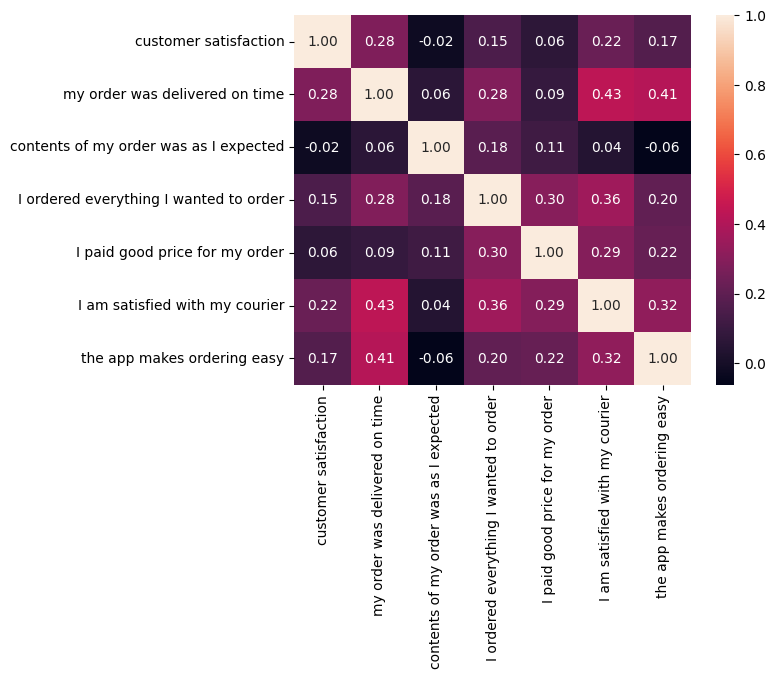

In [17]:
sns.heatmap(data=df.corr(), annot=True, fmt='.2f')
plt.show()

Correlations between predictors and response variable:

my order was delivered on time            0.280160
contents of my order was as I expected   -0.024274
I ordered everything I wanted to order    0.150838
I paid good price for my order            0.064415
I am satisfied with my courier            0.224522
the app makes ordering easy               0.167669
Name: customer satisfaction, dtype: float64


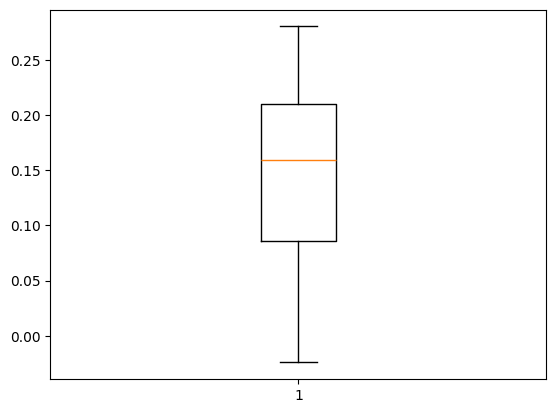

In [18]:
x = df.corr()['customer satisfaction'][1:]
print('Correlations between predictors and response variable:\n')
print(x)

plt.boxplot(x)
plt.show()

### ANOVA f-test

In [19]:
from sklearn.feature_selection import f_classif

y = df['customer satisfaction'].values
X = df.iloc[:, 1:]

[f_stat, f_p_value] = f_classif(X, y)

f_test_df = pd.DataFrame({
    'Feature': df.iloc[:, 1:].columns,
    'f-statistic': f_stat, 'p-value': f_p_value
    })
f_test_df

,Feature,f-statistic,p-value
0,my order was delivered on time,10.561708,0.001486
1,contents of my order was as I expected,0.073084,0.787347
2,I ordered everything I wanted to order,2.886976,0.091806
3,I paid good price for my order,0.516697,0.473606
4,I am satisfied with my courier,6.582690,0.011488
5,the app makes ordering easy,3.586898,0.060567


In [20]:
f_test_df.sort_values('p-value')

,Feature,f-statistic,p-value
0,my order was delivered on time,10.561708,0.001486
4,I am satisfied with my courier,6.582690,0.011488
5,the app makes ordering easy,3.586898,0.060567
2,I ordered everything I wanted to order,2.886976,0.091806
3,I paid good price for my order,0.516697,0.473606
1,contents of my order was as I expected,0.073084,0.787347


In [ ]:
# f_test_df.sort_values(by='p-value').to_csv('../images/p-values.csv')

    "A small p-value indicates that it is unlikely to observe such a substantial association
    between the predictor and the response due to chance, in the absence of
    any real association between the predictor and the response. Hence, if we
    see a small p-value, then we can infer that there is an association between
    the predictor and the response."
    
    - Introduction to Statistical Learning

## Target Variable

In [22]:
print(f"Average satisfaction rate: {df['customer satisfaction'].mean()}\n")
print(df['customer satisfaction'].value_counts())
print()
print(df['customer satisfaction'].value_counts(normalize=True))

Average satisfaction rate: 0.5476190476190477

customer satisfaction
1    69
0    57
Name: count, dtype: int64

customer satisfaction
1    0.547619
0    0.452381
Name: proportion, dtype: float64


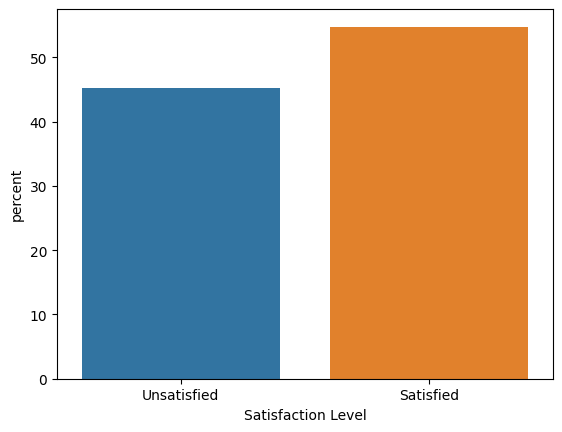

In [23]:
sns.countplot(data=df,
              x='customer satisfaction',
              stat='percent',
              hue='customer satisfaction',
              legend=False
              )
plt.xticks([0,1], ['Unsatisfied', 'Satisfied'])
plt.xlabel('Satisfaction Level')
plt.show()

For our target feature (customer satisfaction) we see that there are only two answers - 1 for satisfied and 0 for unsatisfied. The target feature is also roughly equal - satisfied customers make up ~55% of the dataset and unsatisfied customers make up ~45% of the dataset.

In [33]:
df.groupby('customer satisfaction').agg({np.mean, np.median})

my order was delivered on time         \
                                                mean median   
customer satisfaction                                         
0                                           4.087719    4.0   
1                                           4.536232    5.0   

                      contents of my order was as I expected         \
                                                        mean median   
customer satisfaction                                                 
0                                                   2.561404    3.0   
1                                                   2.507246    2.0   

                      I ordered everything I wanted to order         \
                                                        mean median   
customer satisfaction                                                 
0                                                   3.140351    3.0   
1                                                   3.449275    3.0   

                      I paid good price for my order         \
                                                mean median   
customer satisfaction                                         
0                                           3.684211    4.0   
1                                           3.797101    4.0   

                      I am satisfied with my courier         \
                                                mean median   
customer satisfaction                                         
0                                           3.368421    4.0   
1                                           3.884058    4.0   

                      the app makes ordering easy         
                                             mean median  
customer satisfaction                                     
0                                        4.105263    4.0  
1                                        4.376812    5.0

Looking at both satisfied and disatisfied customers seperately we can see that the satisfied customers have slightly higher averages (as we would expect) except for the question *'contents of my order was as I expected'*; that question had a minimal correlation with the target variable according to the heatmap above. 

The two questions that had more than a 20% correlation with the target variable and whose p-values were significantly low, according to the ANOVA f-test, were *'my order was delivered on time'* and *'I am satisfied with my courier'*. By looking here we see an almost half-point difference between average scores on those two questions. Whereas on the other three we only see no more than a .3 difference.

Eventhough the question *'contents of my order was as I expected'* has little correlation to the target variable, it is concerning that both groups of customers gave that question less than 3 on average. That might be problematic for a food delivery business.

Going forward we will use different models to perform a sort of feature selection to see whether the predictor(s) to look at will be *my order was delivered on time* and/or *I am satisfied with my courier*.

### Top Two Features

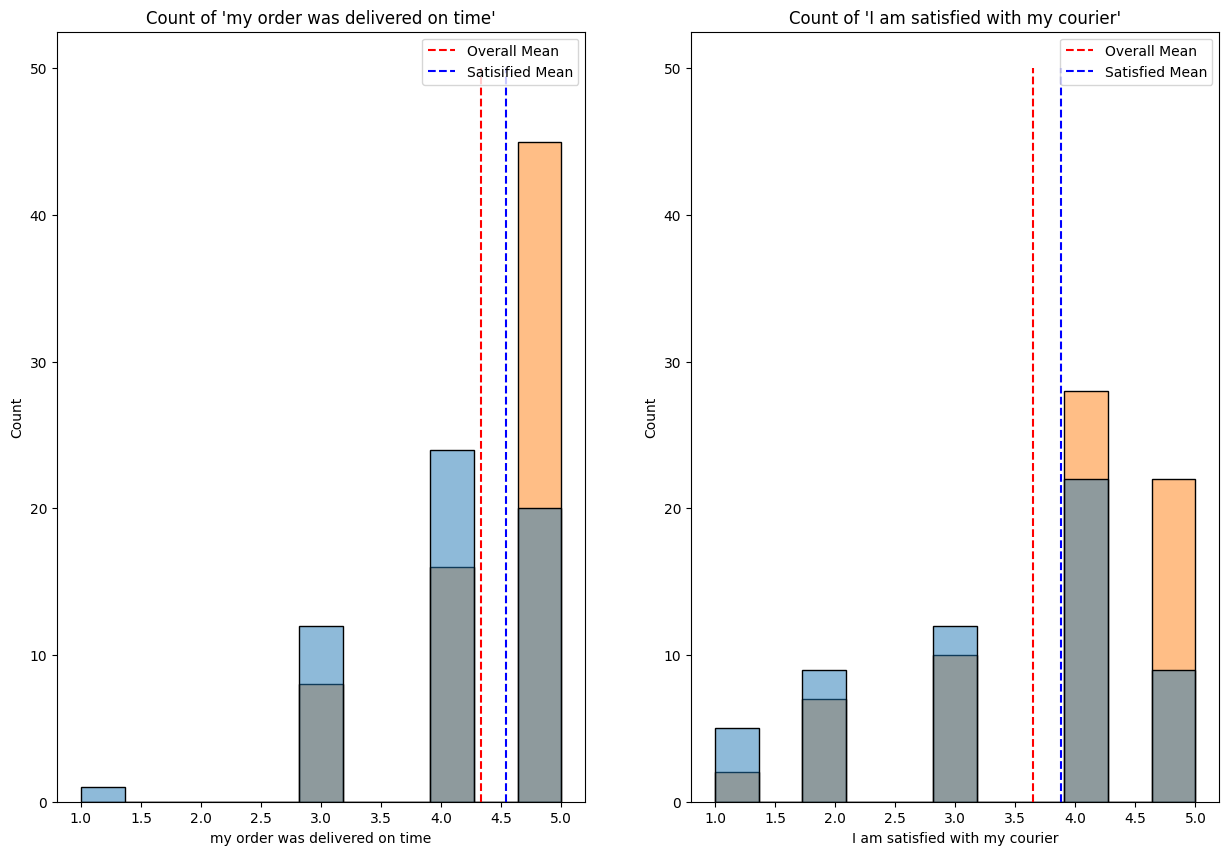

In [125]:
plt.figure(figsize=(15, 10))

plt.subplot(1,2,1)
plt.vlines(df['my order was delivered on time'].mean(), 
           ymin=[0], ymax=[50], color='r', linestyles='--', label='Overall Mean') ## overall mean
plt.vlines(df[df['customer satisfaction']==1]['my order was delivered on time'].mean(),
           ymin=[0], ymax=[50], color='b', linestyles='--', label='Satisified Mean') ## satisfied mean
sns.histplot(hue='customer satisfaction',
             x='my order was delivered on time',
             data=df
             )
plt.title("Count of 'my order was delivered on time'")
plt.legend()


plt.subplot(1,2,2)
plt.vlines(df['I am satisfied with my courier'].mean(),
           ymin=[0], ymax=[50], color='r', linestyles='--', label='Overall Mean') ## overall mean
plt.vlines(df[df['customer satisfaction']==1]['I am satisfied with my courier'].mean(),
           ymin=[0], ymax=[50], color='b', linestyles='--', label='Satisfied Mean') ## satisfied mean
sns.histplot(hue='customer satisfaction',
             x='I am satisfied with my courier',
             data=df
             )
plt.title("Count of 'I am satisfied with my courier'")
plt.legend()
plt.show()

Looking at the top two questions in the light of the logistic regression coefficients, given a satisfied customer there is a liklihood that over 30% ((1-exp(.267268))x100) of the time they will give a higher score than the mean on the question *I am satisified with my courier* than those unsatisfied customers and over a 5% higher score on the question *my order was delivered on time*.

The pruned decision tree model uses a different approach in that if a given customer gave over a 4.5 score on *my order was delivered on time*, then they are ~72% likely to be satisfied.

### Backward Stepwise Selection Process

In [30]:
from sklearn.linear_model import LogisticRegression

## backward stepwise selection
def backward_stepwise_selection(df, target_var_index, random_state=None):
    '''
    parameters:
        df: pandas dataframe
        target_var_index: integer corresponding to target variable index in dataframe
        random_state: seed for reproducibility

    return:
        error: error scores from each iteration of backward stepwise algorithm
        predictor_columns: list of lists of columns used in each iteration...the number of columns in each list should decrease by one from the initial list of columns used.
    '''

    error = []
    predictor_columns = []
    y = df.iloc[target_var_index].values
    predictors = df.drop(df.iloc[target_var_index], axis=1) ## initially whole data set
    # predictors = df.iloc[:, 1:] #

    while len(predictors.columns) >= 1:
        ## for last column
        if len(predictors.columns) == 1:
            # print(len(predictors.columns)) ## should be 1
            # print(predictors.columns)
            predictor_columns.append(predictors.columns)

            lr = LogisticRegression(fit_intercept=True, random_state=random_state)
            lr.fit(predictors, y)
            error_score = 1 - lr.score(predictors, y)
            error.append(error_score)

            X = sm.add_constant(predictors)
            results = sm.Logit(y, X).fit()
            sorted_p_vals = results.pvalues.sort_values().to_frame() ##gets p-values and stores them in pd DataFrame
            sorted_p_vals.drop(sorted_p_vals.index[-1], axis=0, inplace=True)
            break

        # print(len(predictors.columns)) ## should be decreasing incramentally each interation
        # print(predictors.columns)
        predictor_columns.append(predictors.columns)

        lr = LogisticRegression(fit_intercept=True, random_state=random_state)
        lr.fit(predictors, y)
        error_score = 1 - lr.score(predictors, y)
        error.append(error_score)

        X = sm.add_constant(predictors)
        results = sm.Logit(y, X).fit()
        sorted_p_vals = results.pvalues.sort_values().to_frame() ##gets p-values and stores them in pd DataFrame
        sorted_p_vals.drop(sorted_p_vals.index[-1], axis=0, inplace=True)
        try:
            predictors = df[sorted_p_vals.index.drop('const')]
        except:
            predictors = df[sorted_p_vals.index]

    return error, predictor_columns
    